In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
#from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [2]:
input_path = f'/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/data/raw/'
output_path = f'/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/data/processed/'

In [3]:
train_df = pd.read_csv(os.path.join(input_path, 'train_FD001.txt'), sep=r"\s+", header=None)
columns = ( ["engine_id", "cycle"] + [f"operational_setting_{i}" for i in range(1, 4)] + 
           [f"s{i}" for i in range(1, 22)])
train_df.columns = columns

In [4]:
RUL_CAP = 125

max_cycles = (train_df.groupby('engine_id')['cycle'].max().rename('max_cycle'))
train_df = train_df.join(max_cycles, on='engine_id') 
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df['RUL'] = train_df['RUL'].clip(upper = RUL_CAP)       #Cap RUL at RUL_CAP
train_df.drop(columns=['max_cycle'], inplace=True)
train_df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [5]:
test_df = pd.read_csv(os.path.join(input_path, 'test_FD001.txt'), sep=r"\s+", header=None)
test_df.columns = columns
test_df.head()


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [6]:
y_test = pd.read_csv((os.path.join(input_path, 'RUL_FD001.txt')),  sep=r"\s+", header=None)
y_test.columns = ['RUL']
y_test.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [7]:
sensor_col = [f"s{i}" for i in range(1,22)]

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
pca = PCA(n_components=10)

X_train_scaled = scaler.fit_transform(train_df[sensor_col])
X_train_transformed = pca.fit_transform(X_train_scaled)

y_train = train_df['RUL'].values
y_test = y_test


In [10]:
X_train_transformed.mean(), X_train_transformed.std()

(np.float64(2.066432269187437e-18), np.float64(1.194964154757303))

In [11]:
X_test_scaled = scaler.transform(test_df[sensor_col])
X_test_transformed = pca.transform(X_test_scaled)

In [12]:
y_train

array([125, 125, 125, ...,   2,   1,   0], shape=(20631,))

In [13]:
y_test

,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [14]:
print(f'X_train: {X_train_transformed.shape}')
print(f'y_train: {y_train.shape} | range {y_train.min():.0f} - {y_train.max():.0f}')
print(f'X_test: {X_test_transformed.shape}')
print(f'y_test: {y_test.shape} ')

X_train: (20631, 10)
y_train: (20631,) | range 0 - 125
X_test: (13096, 10)
y_test: (100, 1) 


In [15]:
X_train_processed = pd.DataFrame(X_train_transformed, columns=[f"PC{i+1}" for i in range(X_train_transformed.shape[1])])
y_train_processed =  pd.DataFrame(y_train, columns=['RUL'])
X_test_processed = pd.DataFrame(X_test_transformed, columns=[f"PC{i+1}" for i in range(X_train_transformed.shape[1])])
y_test_processed = pd.DataFrame(y_test, columns=['RUL'])


In [16]:
X_train_processed.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-2.944902,-0.452747,0.300691,0.824244,0.629020,-0.344302,-0.032812,0.635351,-0.253381,0.233350
1,-2.360407,-0.795862,0.248736,0.961509,0.285420,-0.022143,0.303058,0.648289,-0.061385,-0.221041
2,-2.979360,-0.549591,0.290127,0.603968,-1.100258,-0.457617,-0.230811,0.106652,0.148599,0.275155
3,-3.384948,-0.841757,0.305124,-0.404573,-0.052269,0.126706,0.112252,-1.127880,-0.329523,0.693301
4,-2.422708,-0.377598,0.289617,-0.716113,0.360137,0.072907,0.494492,0.223097,0.166639,0.088924


In [17]:
y_train_processed.head()

,RUL
0,125
1,125
2,125
3,125
4,125


In [18]:
X_test_processed.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-2.483277,-0.757266,0.250247,-0.357859,-0.827911,0.916252,0.386077,-0.613944,0.464422,-0.498760
1,-3.558058,-0.061954,0.355324,0.585504,1.262378,-0.112146,-0.200068,-0.498812,-0.172233,0.548958
2,-2.339002,-0.374149,0.277194,-0.052414,0.402845,0.678956,0.077540,1.012602,0.231825,-0.050153
3,-2.854791,-0.799181,0.279573,-0.104631,-0.685040,0.029800,-0.243751,-0.177274,-0.660981,0.139938
4,-3.495873,-0.748403,0.315247,0.552925,-1.196128,0.101780,0.128917,0.039915,-0.097733,-0.157832


In [19]:
X_train_processed.to_csv(os.path.join(output_path + f'X_train_processed.csv'), index = False)
y_train_processed.to_csv(os.path.join(output_path + f'y_train_processed.csv'), index = False)
X_test_processed.to_csv(os.path.join(output_path + f'X_test_processed.csv'), index = False)
y_test_processed.to_csv(os.path.join(output_path + f'y_test_processed.csv'), index = False)

In [20]:
y_train_processed.shape, y_test_processed.shape

((20631, 1), (100, 1))

#### Principal components vs RUL

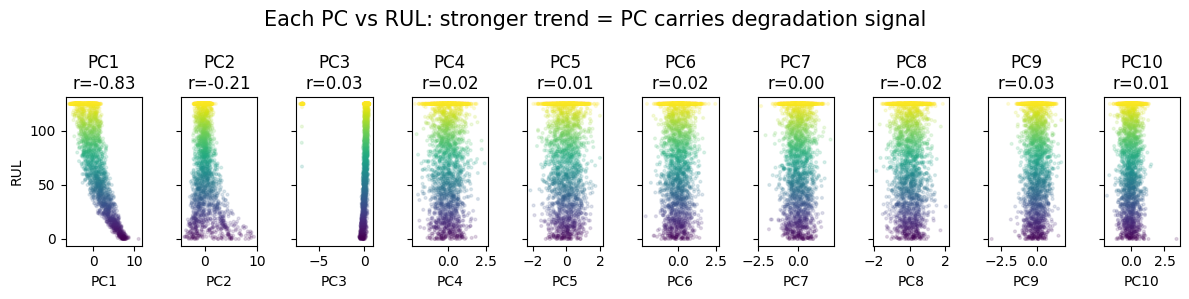

In [21]:
fig, axes = plt.subplots(1, 10, figsize=(12,3), sharey=True)

idx = np.random.choice(len(y_train), 3000, replace=False)

for i, ax in enumerate(axes):
    ax.scatter(X_train_transformed[idx, i], y_train[idx],
               alpha=0.15, s=4, c=y_train[idx], cmap='viridis')
    r = np.corrcoef(X_train_transformed[:, i], y_train)[0, 1]
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel('RUL' if i == 0 else '')
    ax.set_title(f'PC{i+1}\nr={r:.2f}')

plt.suptitle('Each PC vs RUL: stronger trend = PC carries degradation signal',
             fontsize=15)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.show()

#### Evaluation metrics

In [27]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "SVR": SVR()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_processed, y_train_processed) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    test_df["prediction"] = y_test_pred
    y_test_pred = (test_df.groupby("engine_id").tail(1).sort_values("engine_id")["prediction"].values)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train_processed, y_train_pred)
    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test_processed, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 21.5052
- Mean Absolute Error: 17.5812
- R2 Score: 0.7337
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 21.9029
- Mean Absolute Error: 17.6925
- R2 Score: 0.7222




/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 6.8132
- Mean Absolute Error: 4.8516
- R2 Score: 0.9733
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 17.3959
- Mean Absolute Error: 12.5989
- R2 Score: 0.8248


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 12.6261
- Mean Absolute Error: 9.0694
- R2 Score: 0.9082
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 18.4469
- Mean Absolute Error: 13.1065
- R2 Score: 0.8029




/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR
Model performance for Training set
- Root Mean Squared Error: 18.7031
- Mean Absolute Error: 12.4714
- R2 Score: 0.7986
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 19.5342
- Mean Absolute Error: 13.9108
- R2 Score: 0.7790




In [29]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,Random Forest Regressor,0.824760
2,XGBRegressor,0.802945
3,SVR,0.779031
0,Linear Regression,0.722193


In [22]:
X_train_proper = pd.read_csv('/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/X_train_proper.csv')
y_train_proper = pd.read_csv('/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/y_train_proper.csv')

In [23]:
def phm_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    diff = y_pred - y_true   # positive = predicted too high (early), negative = predicted too low (late)
    scores = np.where(diff < 0, np.exp(-diff / 13) - 1,   # late: harsh penalty
                                np.exp( diff / 10) - 1)   # early: softer penalty
    return float(np.sum(scores))

In [24]:
def alpha_lambda_accuracy(y_true, y_pred, alpha=0.20):
    within = np.abs(y_true - y_pred) <= alpha * y_true
    return float(np.mean(within))

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "SVR": SVR()
}

def evaluate_model(y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    bias  = float(np.mean(y_pred - y_true))
    phm   = phm_score(y_true, y_pred)
    al_acc = alpha_lambda_accuracy(y_true, y_pred)
    return rmse, mae, r2, bias, phm, al_acc

results = []

for name, model in models.items():
    model.fit(X_train_proper, y_train_proper)

    y_train_pred = model.predict(X_train_proper)
    y_test_pred  = model.predict(X_test_processed)

    # CMAPSS: align test predictions to last cycle per engine
    test_df["prediction"] = y_test_pred
    y_test_pred_final = (
        test_df.groupby("engine_id")
               .tail(1)
               .sort_values("engine_id")["prediction"]
               .values
    )

    train_metrics = evaluate_model(y_train_proper.values.ravel(), y_train_pred)
    test_metrics  = evaluate_model(y_test_processed.values.ravel(), y_test_pred_final)

    results.append({
        "model":             name,
        "train_rmse":        train_metrics[0],
        "test_rmse":         test_metrics[0],
        "overfit_gap_rmse":  train_metrics[0] - test_metrics[0],
        "test_mae":          test_metrics[1],
        "test_r2":           test_metrics[2],
        "test_bias":         test_metrics[3],
        "test_phm_score":    test_metrics[4],
        "test_al_acc_20pct": test_metrics[5],
    })

results_df = pd.DataFrame(results).sort_values("test_rmse")
results_df

/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,model,train_rmse,test_rmse,overfit_gap_rmse,test_mae,test_r2,test_bias,test_phm_score,test_al_acc_20pct
1,Random Forest Regressor,6.831372,17.431699,-10.600327,12.613000,0.824038,1.956200,980.436951,0.63
2,XGBRegressor,11.769588,19.497627,-7.728040,13.473271,0.779857,2.625917,2657.698725,0.61
3,SVR,18.768957,19.652755,-0.883798,14.117891,0.776341,6.816898,1559.603586,0.61
0,Linear Regression,21.428945,21.880955,-0.452010,17.675479,0.722749,4.014940,1282.160523,0.49


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

y_true = y_test_processed.values.ravel()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("True vs Predicted RUL — baseline models", fontsize=13, y=1.02)

for ax, (name, y_pred) in zip(axes, test_predictions.items()):
    residuals = y_pred - y_true
    rmse  = np.sqrt(np.mean(residuals**2))
    mae   = np.mean(np.abs(residuals))
    r2    = r2_score(y_true, y_pred)
    bias  = np.mean(residuals)
    phm   = phm_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.4, s=18, color="#2a78d6", linewidths=0)
    ax.plot([0, 125], [0, 125], 'r--', lw=1.5, label='perfect')

    # Metrics as text block in top-left corner
    textstr = (
        f"RMSE  {rmse:.1f}\n"
        f"MAE   {mae:.1f}\n"
        f"R²    {r2:.2f}\n"
        f"Bias  {bias:+.1f}\n"
        f"PHM   {phm:.0f}"
    )
    ax.text(
        0.03, 0.97, textstr,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.85)
    )

    ax.set_xlim(0, 130); ax.set_ylim(0, 130)
    ax.set_xlabel("True RUL (cycles)", fontsize=10)
    ax.set_ylabel("Predicted RUL (cycles)", fontsize=10)
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig("artifacts/true_vs_pred_baselines.png", dpi=150, bbox_inches='tight')
plt.show()